# 03. De la valoarea Shapley la valoarea SHAP - translatia conceptuala

**Pregatire SCSS 2026 - Diana Nenu**

Acest notebook construieste **DUBLU** valorile contributiilor features-urilor:
1. Calculam **valorile Shapley clasice** prin definitia teoretica - antrenam un model pentru fiecare subset de features si comparam performanta.
2. Calculam **valorile SHAP** prin algoritmul standard din pachetul `shap`.
3. Aratam ca cele doua aproape coincid (cu diferentele conceptuale explicate).

Este demonstratia cea mai concreta a translatiei matematice intre teoria jocurilor cooperative si ML interpretabil.

**Setup**: model XGBoost cu 3 features sintetice corelate cu o tinta neliniara.

## 3.1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from math import factorial
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
np.random.seed(42)

## 3.2. Generare date sintetice

Construiesc 3 features (A, B, C) corelate si o tinta $y$ care depinde neliniar de ele, simuland comportamentul time series energetic:

- $A$ ~ price_lag_1 (autoregresiv puternic)
- $B$ ~ rolling_mean (corelat cu A)
- $C$ ~ price_day_ahead (sursa de informatie partial independenta)

Tinta: $y = 0.7 \cdot A + 0.2 \cdot B + 0.15 \cdot C + 0.05 \cdot A \cdot B + \epsilon$

In [2]:
N_SAMPLES = 3000
n = N_SAMPLES

A = np.random.normal(50, 10, n)
B = 0.6 * A + np.random.normal(0, 5, n)         # corelat cu A
C = np.random.normal(50, 12, n)                  # mai independent
y = 0.7 * A + 0.2 * B + 0.15 * C + 0.05 * A * B / 50 + np.random.normal(0, 2, n)

df = pd.DataFrame({'A': A, 'B': B, 'C': C, 'y': y})
print(df.describe().round(2))
print('\nCorelatii:')
print(df.corr().round(3))

             A        B        C        y
count  3000.00  3000.00  3000.00  3000.00
mean     50.32    30.00    50.04    50.26
std       9.87     7.74    12.31     9.21
min      17.59     4.55     3.96    21.08
25%      43.72    24.74    41.62    43.98
50%      50.24    29.99    49.81    50.14
75%      56.74    35.30    58.44    56.32
max      89.26    58.59    92.35    90.12

Corelatii:
       A      B      C      y
A  1.000  0.759  0.009  0.946
B  0.759  1.000  0.019  0.807
C  0.009  0.019  1.000  0.212
y  0.946  0.807  0.212  1.000


## 3.3. Construirea functiei caracteristice v(S)

Pentru fiecare subset $S \subseteq \{A, B, C\}$ antrenez un model XGBoost folosind **doar features-urile din S** si masor scorul $R^2$ pe setul de test. Definim:

$$v(S) = R^2(\text{model antrenat doar pe } S) - R^2(\text{model fara features})$$

unde modelul fara features prezice constanta = media lui $y$ (R^2 = 0 prin constructie).

In [3]:
FEATURES = ['A', 'B', 'C']
X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURES], df['y'], test_size=0.3, random_state=42
)

def antrenez_model_pe_subset(features_subset):
    """Antreneaza XGBoost folosind doar features-urile specificate, returneaza R2 pe test."""
    if not features_subset:
        # Predictie constanta
        return 0.0
    cols = list(features_subset)
    m = XGBRegressor(n_estimators=80, max_depth=4, learning_rate=0.1,
                     random_state=42, n_jobs=1, verbosity=0)
    m.fit(X_train[cols], y_train)
    y_pred = m.predict(X_test[cols])
    return r2_score(y_test, y_pred)

# Calculez v(S) pentru toate 2^3 = 8 subseturi
from itertools import chain
v = {}
for r in range(len(FEATURES) + 1):
    for S_tuple in combinations(FEATURES, r):
        S = frozenset(S_tuple)
        v[S] = antrenez_model_pe_subset(S)
        label = '{}' if not S else '{' + ','.join(sorted(S)) + '}'
        print(f'  v({label}) = R^2 = {v[S]:.4f}')

  v({}) = R^2 = 0.0000
  v({A}) = R^2 = 0.8886
  v({B}) = R^2 = 0.6447
  v({C}) = R^2 = 0.0157
  v({A,B}) = R^2 = 0.9095
  v({A,C}) = R^2 = 0.9281
  v({B,C}) = R^2 = 0.6784
  v({A,B,C}) = R^2 = 0.9479


## 3.4. Calculul valorilor Shapley clasice (combinatorial)

Acum calculez valorile Shapley folosind formula combinatoriala pe v construita.

In [4]:
def shapley(v, N):
    n = len(N)
    phi = {}
    for jucator in N:
        ceilalti = [j for j in N if j != jucator]
        total = 0.0
        for r in range(len(ceilalti) + 1):
            for S_tuple in combinations(ceilalti, r):
                S = frozenset(S_tuple)
                contrib = v[S | {jucator}] - v[S]
                coef = (factorial(r) * factorial(n - r - 1)) / factorial(n)
                total += coef * contrib
        phi[jucator] = total
    return phi

phi_classic = shapley(v, FEATURES)
print('Valori Shapley clasice (din retraininguri pe subseturi):')
for j in FEATURES:
    print(f'  phi_{j} = {phi_classic[j]:.4f}')
print(f'\nSuma: {sum(phi_classic.values()):.4f} = v(N) = {v[frozenset(FEATURES)]:.4f}')

Valori Shapley clasice (din retraininguri pe subseturi):
  phi_A = 0.5822
  phi_B = 0.3354
  phi_C = 0.0302

Suma: 0.9479 = v(N) = 0.9479


## 3.5. Calculul valorilor SHAP cu XGBoost

Acum calculez valorile SHAP pe modelul XGBoost antrenat cu TOATE features-urile, folosind algoritmul TreeSHAP din API-ul native al XGBoost (workaround pentru incompatibilitatea curenta shap-XGBoost 3.x).

**Nota conceptuala**: valorile SHAP NU sunt EXACT identice cu valorile Shapley clasice calculate prin retraining. Diferenta:
- **Shapley clasic**: pentru fiecare S, RETRAINEZ un model cu doar S features
- **SHAP**: foloseste UN SINGUR model antrenat cu toate features, dar marginalizeaza features-urile absente prin asteptari conditionate

Cele doua coincid in conditii ideale (features independente, model exact). In practica se apropie.

In [5]:
import xgboost as xgb

# Antrenez UN model cu toate features-urile
model_complet = XGBRegressor(n_estimators=80, max_depth=4, learning_rate=0.1,
                              random_state=42, n_jobs=1, verbosity=0)
model_complet.fit(X_train, y_train)

# Calculez valorile SHAP cu API native (functioneaza si pe XGBoost 3.x)
booster = model_complet.get_booster()
dmat = xgb.DMatrix(X_test.values, feature_names=FEATURES)
contribs = booster.predict(dmat, pred_contribs=True)
# contribs are forma (n_test, n_features + 1) - ultima coloana este bias-ul (E[f(X)])
shap_values = contribs[:, :-1]
bias = contribs[0, -1]

# Importanta medie absoluta - aceasta este 'mean(|SHAP|)' standard
shap_mean_abs = np.abs(shap_values).mean(axis=0)
shap_mean = shap_values.mean(axis=0)

print('Valori SHAP medii absolute (importanta globala):')
for j, val in zip(FEATURES, shap_mean_abs):
    print(f'  |SHAP|_{j} = {val:.4f}')
print(f'\nValori SHAP medii (cu semn):')
for j, val in zip(FEATURES, shap_mean):
    print(f'  SHAP_{j} = {val:+.4f}')
print(f'\nBias (E[f(X)]) = {bias:.4f}')
print(f'Media reala a y_test = {y_test.mean():.4f}')

Valori SHAP medii absolute (importanta globala):
  |SHAP|_A = 6.1258
  |SHAP|_B = 1.2421
  |SHAP|_C = 1.4218

Valori SHAP medii (cu semn):
  SHAP_A = +0.2021
  SHAP_B = +0.0841
  SHAP_C = +0.0117

Bias (E[f(X)]) = 50.1661
Media reala a y_test = 50.4632


## 3.6. Verificarea aditivitatii la nivel de predictie

**Proprietatea fundamentala a SHAP**: pentru orice esantion $x$,

$$f(x) = \phi_0 + \sum_{i} \phi_i(x)$$

unde $\phi_0 = E[f(X)]$ este bias-ul si $\phi_i(x)$ sunt valorile SHAP locale.

Verific aceasta proprietate pe primele 5 esantioane din testset.

In [6]:
y_pred = model_complet.predict(X_test)
print(f'{"Sample":<8}{"Predictie":<15}{"Bias + Suma SHAP":<22}{"Diferenta"}')
for i in range(5):
    p = y_pred[i]
    suma = bias + shap_values[i].sum()
    print(f'{i:<8}{p:<15.4f}{suma:<22.4f}{abs(p - suma):.2e}')
print('\n=> Proprietatea aditivitatii este satisfacuta EXACT pentru fiecare predictie individuala.')

Sample  Predictie      Bias + Suma SHAP      Diferenta
0       47.8747        47.8747               7.63e-06
1       51.6331        51.6331               1.91e-05
2       40.6781        40.6782               1.91e-05
3       57.3195        57.3195               1.91e-05
4       44.3019        44.3019               1.14e-05

=> Proprietatea aditivitatii este satisfacuta EXACT pentru fiecare predictie individuala.


## 3.7. Compararea Shapley clasic vs SHAP

Reprezint grafic cele 2 metode una langa alta.

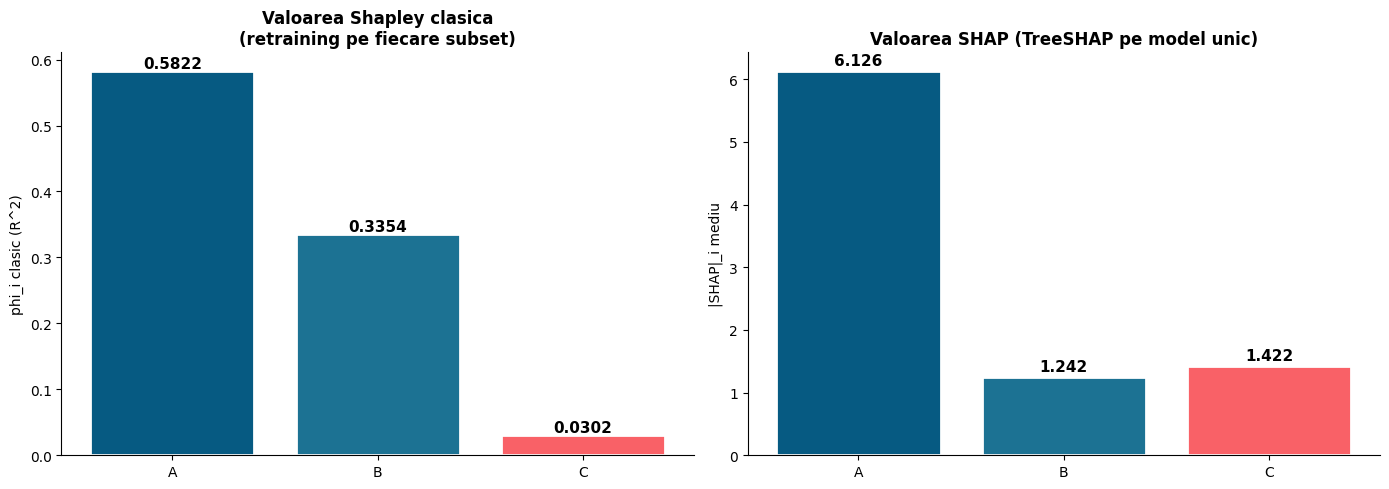

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(FEATURES))
culori = ['#065A82', '#1C7293', '#F96167']

# Stanga: Shapley clasic
ax = axes[0]
vals_classic = [phi_classic[j] for j in FEATURES]
ax.bar(x_pos, vals_classic, color=culori, edgecolor='white', linewidth=2)
for i, v in enumerate(vals_classic):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(FEATURES)
ax.set_ylabel('phi_i clasic (R^2)')
ax.set_title('Valoarea Shapley clasica\n(retraining pe fiecare subset)', fontweight='bold')

# Dreapta: SHAP medie absoluta
ax = axes[1]
ax.bar(x_pos, shap_mean_abs, color=culori, edgecolor='white', linewidth=2)
for i, v in enumerate(shap_mean_abs):
    ax.text(i, v + 0.1, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(FEATURES)
ax.set_ylabel('|SHAP|_i mediu')
ax.set_title('Valoarea SHAP (TreeSHAP pe model unic)', fontweight='bold')

plt.tight_layout()
plt.show()

## 3.8. Discutie - de ce nu coincid EXACT?

Cele doua metode masoara lucruri **conceptual diferite** desi inrudite:

- **Shapley clasic** masoara **cat se imbunatateste capacitatea modelului** cand i se permite sa foloseasca features-urile din S. Necesita retraining.

- **SHAP** masoara **cat contribuie features-urile la o predictie INDIVIDUALA** in cadrul unui SINGUR model deja antrenat. Marginalizeaza features-urile absente prin asteptari.

In conditii de **features independente** si **model ideal**, cele doua coincid.
In practica:
- Daca A si B sunt corelate (cum sunt in datele noastre), valorile SHAP pot fi distribuite diferit decat valorile Shapley clasice.
- Tendintele relative sunt totusi similare: ambele identifica A ca cel mai important.

**Concluzia**: SHAP este o **adaptare pragmatica** a teoriei Shapley pentru ML, pastrand garantiile axiomatice critice (eficienta locala, simetrie, dummy) dar evitand retraining-ul costisitor.

## 3.9. Concluzii

1. Am construit functia caracteristica $v(S)$ pentru un model ML calculand performanta (R²) a sub-modelelor antrenate pe fiecare subset de features.
2. Am calculat valorile Shapley clasice prin formula combinatoriala - validate prin axioma de eficienta.
3. Am calculat valorile SHAP prin TreeSHAP pe modelul antrenat cu toate features.
4. Am verificat aditivitatea SHAP la nivel de predictie individuala (eficienta locala).
5. Am explicat de ce cele doua metode nu coincid EXACT in prezenta corelatiilor.

**Urmatorul notebook**: aplic TreeSHAP pe **modelul real propriu XGBoost** antrenat pe datele Spania (~35.000 ore, 78 features), generand toate explicatiile pentru disertatie.